In [22]:
%pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
data = pd.read_excel("./fraud_data_lyst1751134022071.xlsx")
data.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-04-01 00:58:00,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,2019-04-01 15:06:00,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,2019-04-01 22:37:00,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,2019-04-01 23:06:00,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,2019-04-01 23:59:00,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


In [25]:
data.shape

(14446, 15)

## Population Mean

In [26]:
population_mean = data['amt'].mean()
print("Population mean is: ", population_mean)

Population mean is:  124.43007337671327


### Sample Mean

In [27]:
sample = data['amt'].sample(n=1000, random_state=42)
sample_mean = sample.mean()
print("Sample mean: ", sample_mean)

Sample mean:  119.54582999999998


#### Impact of sample size on sample mean : As the sample size increases, the sample mean becomes better estimator of the population mean. This is one of the key ideas of the Central Theorem

In [28]:
sample_sizes = [10, 50, 100, 500, 1000, 5000, 7000]

sample_means = [data['amt'].sample(n=size, random_state=42).mean() for size in sample_sizes]

for size, mean in zip(sample_sizes, sample_means):
    print(f'Sample size: {size}, Sample mean: {mean}')

Sample size: 10, Sample mean: 96.85499999999999
Sample size: 50, Sample mean: 88.3492
Sample size: 100, Sample mean: 81.8355
Sample size: 500, Sample mean: 112.06866000000001
Sample size: 1000, Sample mean: 119.54582999999998
Sample size: 5000, Sample mean: 123.99536800000001
Sample size: 7000, Sample mean: 126.52721


### Visualize the CLT

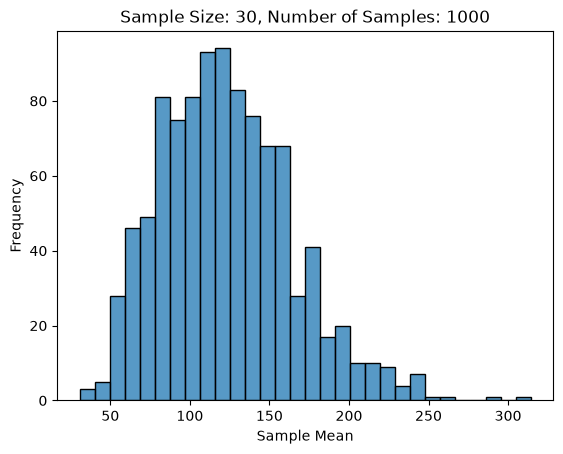

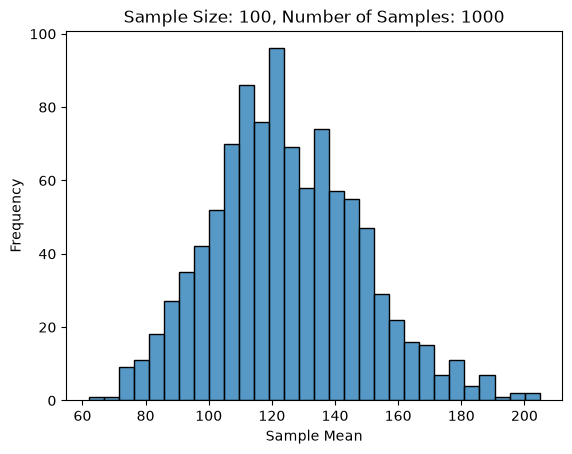

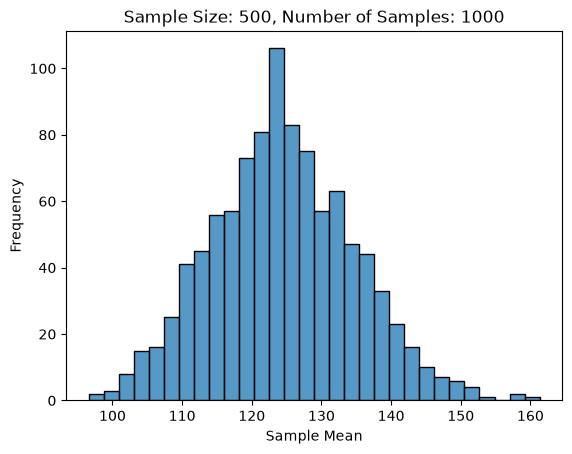

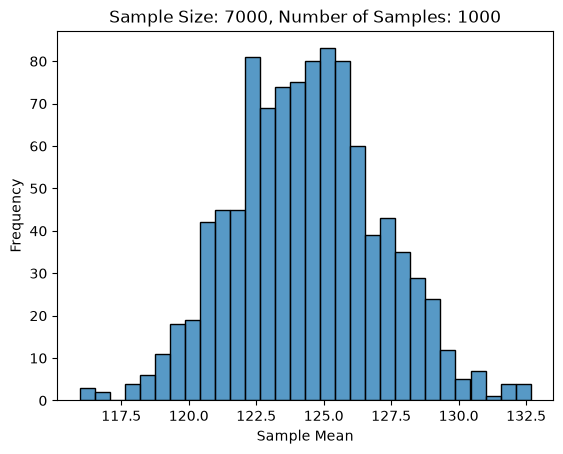

In [29]:
def visualize_clt(data, sample_size, num_samples):
    sample_means = [np.mean(np.random.choice(data, sample_size)) for _ in range(num_samples)]
    sns.histplot(sample_means, bins=30, edgecolor = 'black')
    plt.title(f'Sample Size: {sample_size}, Number of Samples: {num_samples}')
    plt.xlabel('Sample Mean')
    plt.ylabel('Frequency')
    plt.show()

## Function call

visualize_clt(data['amt'], sample_size=30, num_samples=1000)
visualize_clt(data['amt'], sample_size=100, num_samples=1000)
visualize_clt(data['amt'], sample_size=500, num_samples=1000)
visualize_clt(data['amt'], sample_size=7000, num_samples=1000)



## Difference between Sample mean vs Sampling distribution mean

### Sample mean : A mean of a single sample
### Sample distribution mean : The mean of all the possible sample means which approximates to population mean

In [30]:
sample_mean_distribution = [np.mean(np.random.choice(data['amt'], size=100)) for _ in range(1000)]
sample_mean_distribution

[np.float64(141.02249999999998),
 np.float64(129.0569),
 np.float64(90.7993),
 np.float64(148.71050000000002),
 np.float64(102.33249999999998),
 np.float64(130.5024),
 np.float64(145.28529999999998),
 np.float64(110.03970000000001),
 np.float64(138.725),
 np.float64(89.112),
 np.float64(152.56429999999997),
 np.float64(128.1653),
 np.float64(145.56760000000003),
 np.float64(114.07770000000001),
 np.float64(108.83179999999999),
 np.float64(179.1306),
 np.float64(145.1984),
 np.float64(145.4504),
 np.float64(126.1241),
 np.float64(109.6476),
 np.float64(166.31950000000003),
 np.float64(142.7027),
 np.float64(111.11449999999999),
 np.float64(95.67099999999999),
 np.float64(142.6616),
 np.float64(104.74829999999999),
 np.float64(140.7548),
 np.float64(126.19780000000003),
 np.float64(98.06929999999998),
 np.float64(132.7875),
 np.float64(100.8401),
 np.float64(134.06560000000002),
 np.float64(125.46170000000002),
 np.float64(100.5058),
 np.float64(157.6014),
 np.float64(131.28709999999998)

In [31]:
sampling_distribution_mean = np.mean(sample_mean_distribution)
sampling_distribution_mean

np.float64(124.1388716)

### Standard deviation of sample mean distribution = sigma(population std devation)/root(n).  

This also term also called standard error 

#### Standard deviation = measure of the spread of the individual data points in the population 
#### Standard error = Measure of the spread of sample mean around the population mean

In [35]:

population_std = data['amt'].std()
population_std

np.float64(231.35258718833182)

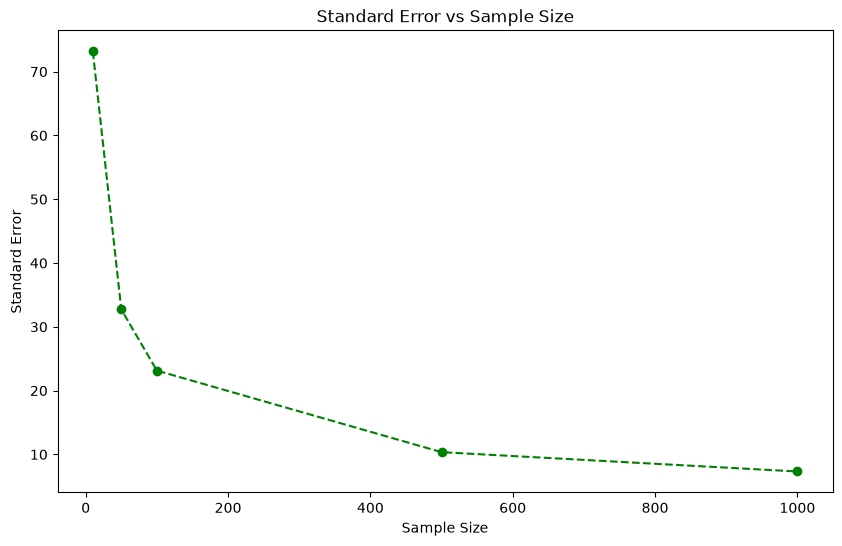

In [39]:
sample_sizes = [10, 50, 100, 500, 1000]
standard_errors = [population_std/np.sqrt(sample_size) for sample_size in sample_sizes]

plt.figure(figsize=(10,6))
plt.plot(sample_sizes, standard_errors, marker = 'o', linestyle = '--', color= 'green')
plt.title("Standard Error vs Sample Size")
plt.xlabel('Sample Size')
plt.ylabel('Standard Error')
plt.show()

### From above graph we can see as we increase the sample size the standard error will decrease
